# **LABORATORIO 12: MODELO REDES BAYESIANAS**

## **Acerca de la data**

This paper contains data for the estimation of obesity levels in people from the countries of Mexico, Peru and Colombia, with ages between 14 and 61 and diverse eating habits and physical condition as mentioned by [1], data was collected using a web platform with a survey (see Table 1) where anonymous users answered each question, then the information was processed obtaining 17 attributes and 2111 records, after a balancing process described in Fig. 1, Fig. 2. The attributes related with eating habits are: **Frequent consumption of high caloric food (FAVC), Frequency of consumption of vegetables (FCVC), Number of main meals (NCP), Consumption of food between meals (CAEC), Consumption of water daily (CH20), and Consumption of alcohol (CALC). The attributes related with the physical condition are: Calories consumption monitoring (SCC), Physical activity frequency (FAF), Time using technology devices (TUE), Transportation used (MTRANS)**, other variables obtained were: Gender, Age, Height and Weight. Finally, all data was labeled and the class variable NObesity was created with the values of: Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III, based on Equation (1) and information from WHO and Mexican Normativity. The data contains numerical data and continous data, so it can be used for analysis based on algorithms of classification, prediction, segmentation and association. Data is available in CSV format and ARFF format to be used with the Weka tool.

Table 1. Questions of the survey used for initial recollection of information.

Questiors
¿What is your gender?
•
Femle
•
Male
¿what is your age?	Numeric value
¿what is your height?	Numeric value in meters
¿what is your weight?	Numeric value in kilograms
¿Has a family member suffered or suffers from oveweigh?	
•
Yes
•
No
¿Do you eat high caloric foo freqently?	
•
Yes
•
No
¿Do you usually eat vegetabes in yur meals?	•
Never
•
Sometimes
•
Always
¿How many mainmeals do you hae daily	
•
Between 1 y 2
•
Three
•
More than three
¿Doyou at any foodbetween meal?	
•
No
•
Sometimes•
Frquently
•
Always
¿Do you smoke?	
•
Ys
•
No
¿How muchwater do you drink aily?	
•
Less than a liter
•
Between 1 and 2 L
•
More han 2L
¿Do you monitor the calories you eat daily?	
•
Yes
•
No¿How often doyou have physcal activity?	
•
I do not have
•
1 or 2 days
•
2 or 4 days
•
4 or 5 days
¿How much time do you use technological devics such as cll phone, vMeogames, television, computer and others?	
•
0–2 hurs
•
3–5 hour
•
More tan 5 hours
how often do you drink alcohol?	
•
I do not drink
•
Sometime
•
Frequetly
•
Always
¿Which transpotation do you usually use?	
•
Automobile
•
Motorbike
•
Bike
•
Public Transportation
•
Walking

## **PARTE A: Exploración de los datos**

### **Importación de librerías y estructura de la data**

In [1]:
# Importación de librerías
import pandas as pd # Trabajar con datos estructurados
import numpy as np
from IPython.display import display, HTML # Visualización de objetos
import matplotlib.pyplot as plt # Visualización de gráficos
import seaborn as sns # Visualización de gráficos
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Lectura de la data
file = "obesidad.csv"
data = pd.read_csv(file)
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
# Se revisa la estructura del DataFrame
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   int64  
 7   NCP                             2111 non-null   int64  
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   int64  
 11  SCC                             2111 non-null   object 
 12  FAF                             21

### **Análisis de datos faltantes**

In [4]:
# Se revisan los valores faltantes
data.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

No se presentan valores faltantes en la data

### **Tratamiento de outliers**

#### **Separación variables numéricas y categóricas**

In [5]:
# Se separa el dataframe en variables numéricas y categóricas)
data_numeric = data.select_dtypes(include = 'number')
data_no_numeric = data.select_dtypes(exclude = 'number')

# Se muestra el dataframe de variables numéricas
display(HTML("<h4>DataFrame de variables numéricas</h4>"))
display(data_numeric.head())

# Se muestra el dataframe de variables no numéricas
display(HTML("<h4>DataFrame de variables no numéricas</h4>"))
display(data_no_numeric.head())

# --- 2. Definir cuáles de las columnas numéricas deben tratarse como categóricas ---
# (Puedes ajustar esta lista según tus datos reales)
integer_categorical_cols = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,21,1.62,64.0,2,3,2,0,1
1,21,1.52,56.0,3,3,3,3,0
2,23,1.80,77.0,2,3,2,2,1
3,27,1.80,87.0,3,3,2,2,0
4,22,1.78,89.8,2,1,2,0,0


,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,Female,yes,no,Sometimes,no,no,no,Public_Transportation,Normal_Weight
1,Female,yes,no,Sometimes,yes,yes,Sometimes,Public_Transportation,Normal_Weight
2,Male,yes,no,Sometimes,no,no,Frequently,Public_Transportation,Normal_Weight
3,Male,no,no,Sometimes,no,no,Frequently,Walking,Overweight_Level_I
4,Male,no,no,Sometimes,no,no,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
# Se revisan las estadísticas descriptivas de las variables numéricas
data_numeric.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701620,86.585978,2.423496,2.687826,2.014685,1.006632,0.664614
std,6.357078,0.093368,26.191165,0.583905,0.809680,0.688616,0.895462,0.674009
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.630000,65.450000,2.000000,3.000000,2.000000,0.000000,0.000000
50%,23.000000,1.700000,83.000000,2.000000,3.000000,2.000000,1.000000,1.000000
75%,26.000000,1.770000,107.450000,3.000000,3.000000,2.000000,2.000000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


#### **Análisis univariado**

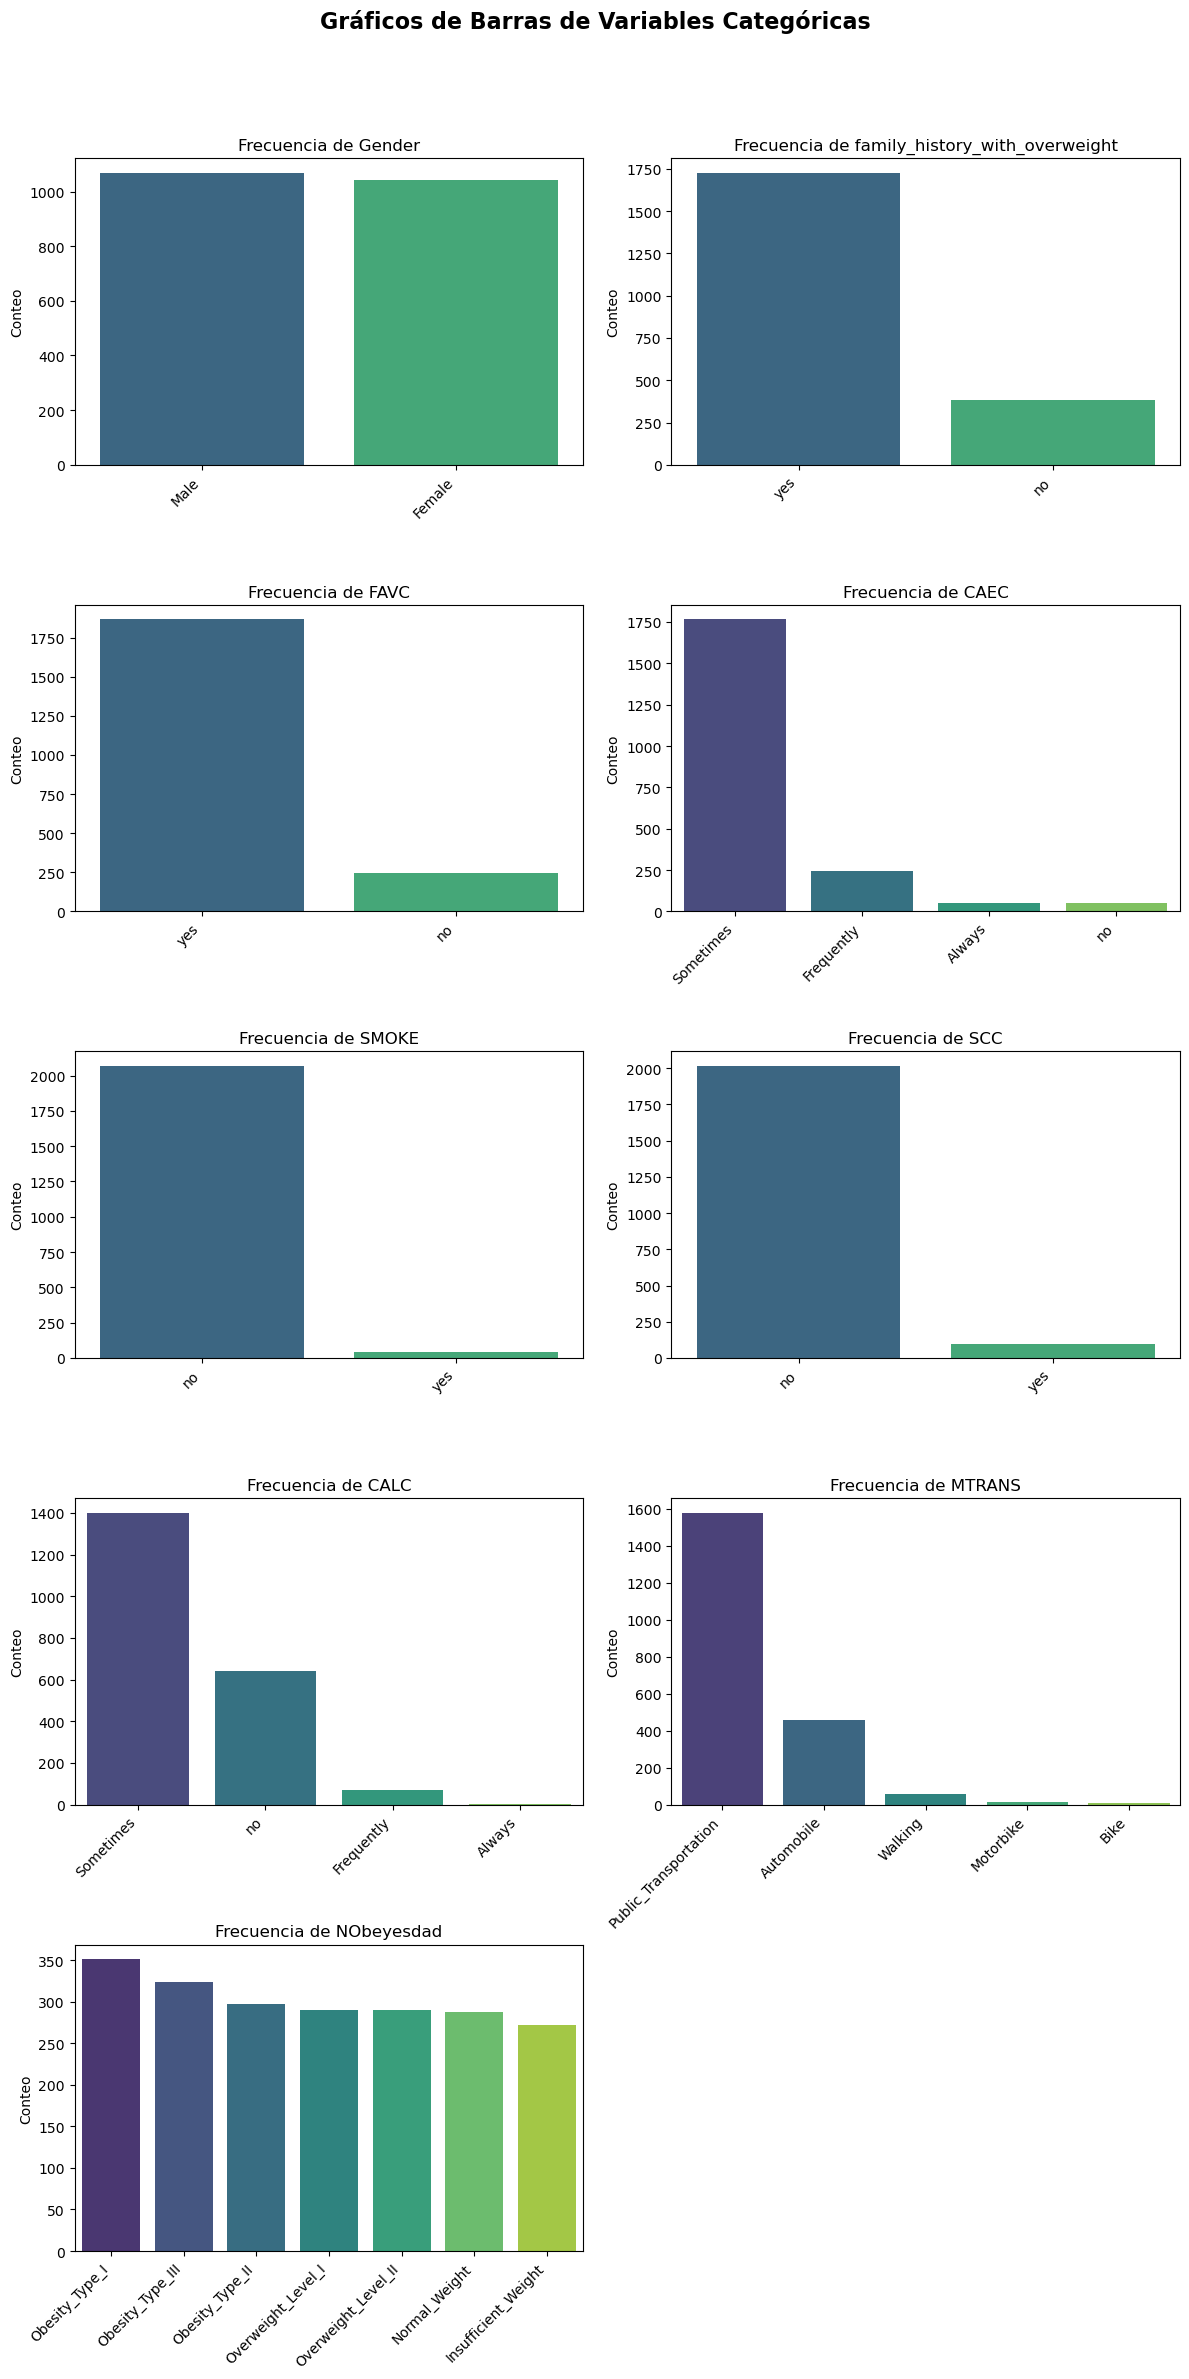

In [7]:
# Obtener los nombres de las columnas (variables categóricas)
categorical_columns = data_no_numeric.columns

# Determinar el número de filas y columnas para la cuadrícula de subgráficos
num_cols = 2  # Cantidad de columnas
num_rows = (len(categorical_columns) + num_cols - 1) // num_cols # Cálculo de filas necesarias

plt.figure(figsize=(12, 5 * num_rows)) # Se ajusta el tamaño general de la figura

# Agrega el título general
plt.suptitle("Gráficos de Barras de Variables Categóricas", fontsize=16, weight='bold')

for i, column in enumerate(categorical_columns):
    plt.subplot(num_rows, num_cols, i + 1) # Crea un subgráfico
    # Cambiamos 'y=column' a 'x=column' para barras verticales
    sns.countplot(x=column, data=data_no_numeric, palette='viridis', order=data_no_numeric[column].value_counts().index)
    plt.title(f'Frecuencia de {column}')
    plt.xlabel('') # Quitar la etiqueta del eje X repetida
    plt.ylabel('Conteo') # Etiqueta el eje Y como 'Conteo'
    plt.xticks(rotation=45, ha='right') # Rotar las etiquetas del eje X para evitar superposición

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta la gráfica para dejar espacio al suptitle
plt.show()


Variables numéricas continuas: ['Age', 'Height', 'Weight']
Variables categóricas (tipo entero): ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


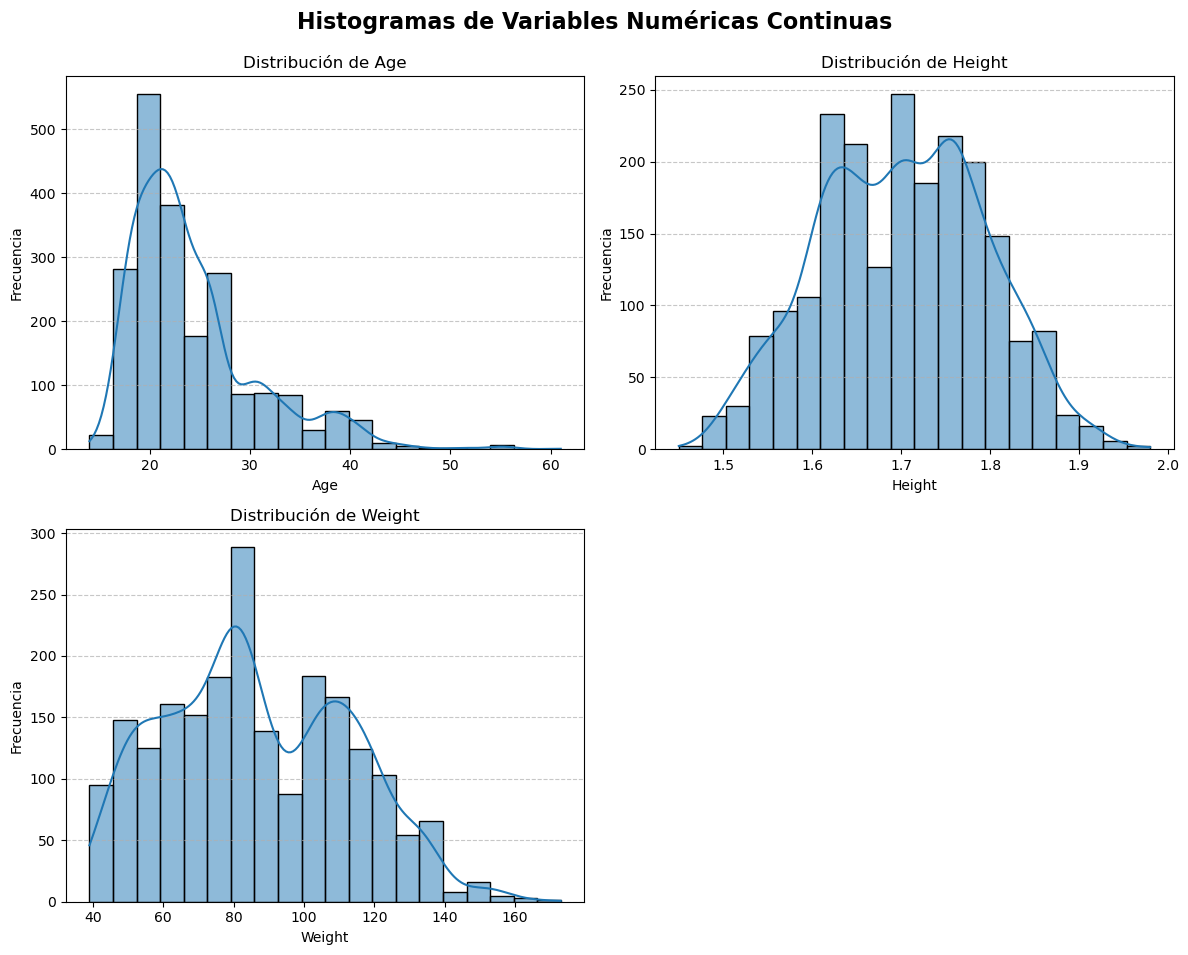

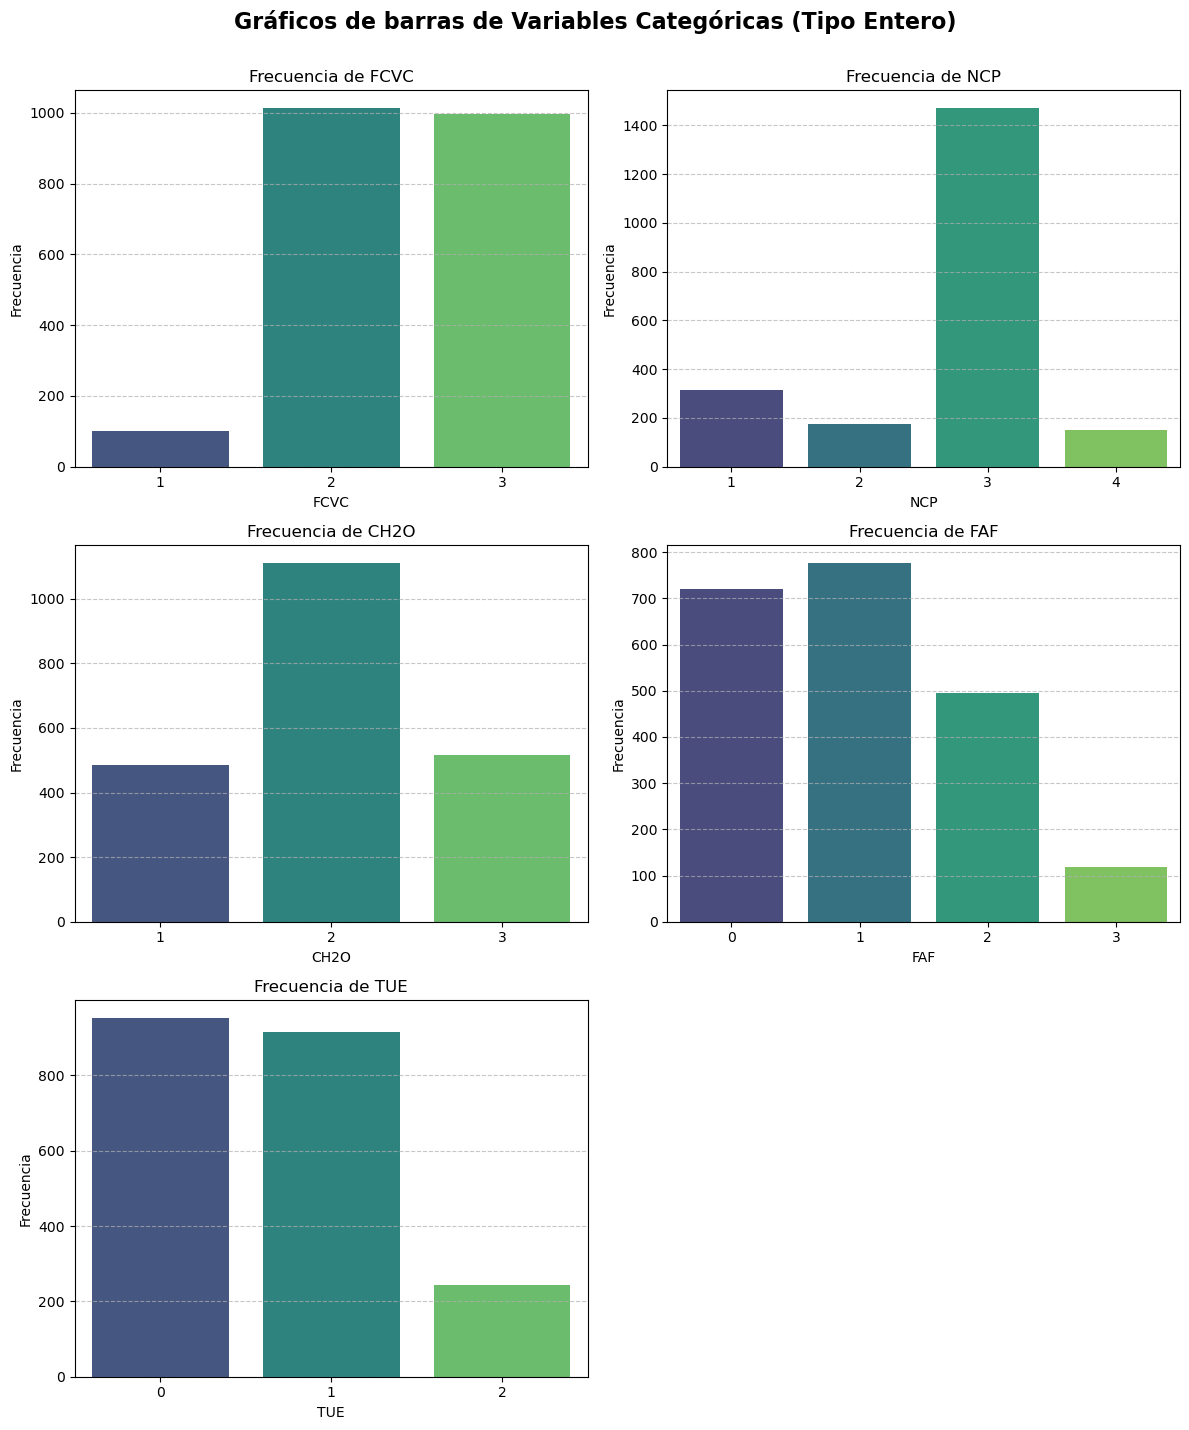

In [8]:
# Se definen las variables numéricas categóricas de tipo entero
integer_categorical_cols = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Se separan las columnas en numéricas no categóricas y categóricas de tipo entero
continuous_numeric_cols = [col for col in data_numeric.columns if col not in integer_categorical_cols]

print(f"\nVariables numéricas continuas: {continuous_numeric_cols}")
print(f"Variables categóricas (tipo entero): {integer_categorical_cols}")

# Se genera el gráfico de Histogramas de Variables Numéricas No Categóricas
if continuous_numeric_cols:
    n_cols_cont = 2 # Cantidad de columnas
    n_rows_cont = (len(continuous_numeric_cols) + n_cols_cont - 1) // n_cols_cont # Cálculo de cantidad de filas

    plt.figure(figsize=(n_cols_cont * 6, n_rows_cont * 5))
    for i, col in enumerate(continuous_numeric_cols):
        plt.subplot(n_rows_cont, n_cols_cont, i + 1)
        sns.histplot(data_numeric[col].dropna(), kde=True, bins=20)
        plt.title(f'Distribución de {col}', fontsize=12)
        plt.xlabel(col, fontsize=10)
        plt.ylabel('Frecuencia', fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle("Histogramas de Variables Numéricas Continuas", fontsize=16, weight='bold')
    plt.show()
else:
    print("\nNo se encontraron variables numéricas continuas para graficar.")

# Se genera el gráfico de Histogramas de Variables Numéricas Categóricas
if integer_categorical_cols:
    n_cols_cat = 2 # Cantidad de columnas
    n_rows_cat = (len(integer_categorical_cols) + n_cols_cat - 1) // n_cols_cat # Cálculo de cantidad de filas

    plt.figure(figsize=(n_cols_cat * 6, n_rows_cat * 5))
    for i, col in enumerate(integer_categorical_cols):
        plt.subplot(n_rows_cat, n_cols_cat, i + 1)
        ordered_values = sorted(data_numeric[col].dropna().unique()) # Se ordenan las variables según categoría (menor al mayor)
        sns.countplot(x=data_numeric[col].astype('category'), palette='viridis', order=ordered_values)
        plt.title(f'Frecuencia de {col}', fontsize=12)
        plt.xlabel(col, fontsize=10)
        plt.ylabel('Frecuencia', fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle("Gráficos de barras de Variables Categóricas (Tipo Entero)", fontsize=16, weight='bold')
    plt.show()
else:
    print("\nNo se encontraron variables categóricas de tipo entero para graficar.")

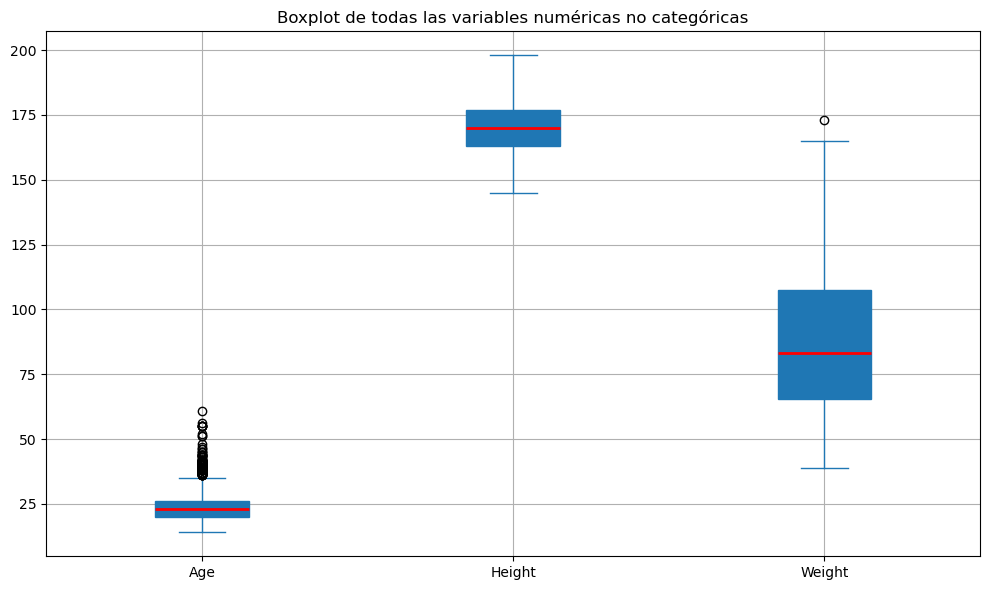

In [9]:
# Se mostrarán los diagramas de caja de todas las variables numéricas no  categóricas para visualizar outliers
data_num_cont = data_numeric[continuous_numeric_cols].copy()
data_num_cont['Height'] = data_num_cont['Height']*100 # Se convierte la altura a centímetros para mejorar la visualización
boxplot = data_num_cont.plot(kind='box', patch_artist=True, grid=True, figsize=(10, 6))

# Resaltar estilo de líneas de la mediana
for line in boxplot.lines[4::6]:  # En matplotlib, cada boxplot tiene 6 líneas. La 5ta es la mediana.
    line.set_color('red') # Formato de color
    line.set_linewidth(2)  # Formato de grosor

# Mostrar gráfica
plt.title('Boxplot de todas las variables numéricas no categóricas') # Título de la gráfica
plt.tight_layout() # Se ajusta automáticamente los espacios de los elementos del gráfico
plt.show()

In [10]:
# Detección outliers fuera del rango intercuartil
for col in data_num_cont:
    Q1 = data_num_cont[col].quantile(0.25)
    Q3 = data_num_cont[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = data_num_cont[(data_num_cont[col] < lower_bound) | (data_num_cont[col] > upper_bound)].shape[0]
    print(f"Variable '{col}': {outliers_count} outliers detectados")

Variable 'Age': 160 outliers detectados
Variable 'Height': 0 outliers detectados
Variable 'Weight': 1 outliers detectados


Se observa que en la variable 'Age' tiene una asimetría positiva, con una cantiad de 160 encuestados con una edad superior al rango intercuartil. Sin embargo, esto no implicaría necesariamente datos atípicos. Se corroborará con un análisis multivariado.

#### **Análisis multivariado: Distancias de Mahalanobis**

In [11]:
from scipy.stats import chi2
from scipy.spatial.distance import cdist

# Se calcula la media, la matriz de covarianza y su inversa
mean = data_num_cont.mean(axis=0)
cov_matrix = np.cov(data_num_cont.T) # Se transpone el Dataframe (se requiere que las variables esten en la las filas y las observaciones en columnas)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Distancia de Mahalanobis
mahalanobis_distances = cdist(data_num_cont, mean.values.reshape(1, -1), metric='mahalanobis', VI=inv_cov_matrix).flatten()

# Se crea y se muestra una copia del Dataframe con las distancias de Mahalanobis
data_dist_mah = data_num_cont.copy()
data_dist_mah['mahalanobis'] = mahalanobis_distances
display(HTML("<h4>DataFrame con distancias de Mahalanobis</h4>"))
display(data_dist_mah.head())

# Se muestran los estadísticos descriptivos de las distancias obtenidas
display(HTML("<h4>Estadísticos de distancias de Mahalanobis</h4>"))
display(data_dist_mah['mahalanobis'].describe())

# Se define y se muestra el umbral en función del número de variables df (grados de libertad)
display(HTML("<h4>Parámetros de umbral de Chi-cuadrado</h4>"))
threshold = chi2.ppf(0.99, df=data_num_cont.shape[1])  # Umbral para 99% de confianza
display(f"Umbral de Chi-cuadrado: {threshold:.2f}")

# Se identifican y se eliminan los outliers
outliers = mahalanobis_distances > threshold # Array booleano
display(f"Se han detectado {outliers.sum()} outliers.")

# Filtrar los datos sin los outliers
data_clean = data_num_cont[~outliers]

# Verificar la forma de los datos antes y después
display(f"Tamaño original: {data_num_cont.shape}")
print(f"Tamaño después de eliminar outliers: {data_clean.shape}")

,Age,Height,Weight,mahalanobis
0,21,162.0,64.0,1.103452
1,21,152.0,56.0,2.034570
2,23,180.0,77.0,1.427895
3,27,180.0,87.0,1.322325
4,22,178.0,89.8,0.933694


count    2111.000000
mean        1.598384
std         0.666301
min         0.071908
25%         1.131045
50%         1.557816
75%         1.981304
max         6.140171
Name: mahalanobis, dtype: float64

'Umbral de Chi-cuadrado: 11.34'

'Se han detectado 0 outliers.'

'Tamaño original: (2111, 3)'

Tamaño después de eliminar outliers: (2111, 3)


Mediante un análisis multivariado, se observa que no se cuentan con combinaciones de registros atípicos por eliminar.

### **Balanceo de clases**

In [12]:
# Se revisa la frecuencia absoluta de la variable objetivo
display(HTML("<h4>Frecuencia Absoluta</h4>"))
display(data['NObeyesdad'].value_counts())

display(HTML("<h4>Frecuencia Relativa</h4>"))
display((data['NObeyesdad'].value_counts(normalize=True) * 100).round(2))

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

NObeyesdad
Obesity_Type_I         16.63
Obesity_Type_III       15.35
Obesity_Type_II        14.07
Overweight_Level_I     13.74
Overweight_Level_II    13.74
Normal_Weight          13.60
Insufficient_Weight    12.88
Name: proportion, dtype: float64

Se observa que las clases están balanceadas y no se requiere generar muestras sintéticas.

## **PARTE B: Transformación de datos**

Estrategia de transformación para el Modelo Naive Bayes:

1) Variables categóricas de tipo entero: se mantienen como entero
2) Variables numéricas ordinales ('CALC' y 'CAEC'): se convierten a tipo entero
3) Variables categóricas: se convierten a dummies

### **Transformación de variables numéricas ordinales**

In [13]:
# Variable 'CAEC': Consumo de alimentos entre comidas ('no','Sometimes','Frecuently','Always')
# Variable 'CALC': Consumo de alcohol ('no','Sometimes','Frecuently','Always')
mapping = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}

data_num_ord_transformed = data_no_numeric[['CAEC','CALC']].copy()
data_num_ord_transformed['CAEC_encoded'] = data_num_ord_transformed['CAEC'].map(mapping)
data_num_ord_transformed['CALC_encoded'] = data_num_ord_transformed['CALC'].map(mapping)

# Se eliminan las variables originales tipo cadena
data_num_ord_transformed = data_num_ord_transformed.drop(columns=['CAEC', 'CALC'])

print(data_num_ord_transformed.head())

   CAEC_encoded  CALC_encoded
0             1             0
1             1             1
2             1             2
3             1             2
4             1             1


In [14]:
# Se verifican las frecuencias de las variables transformadas
display(HTML("<h4>Tabla de frecuencias CAEC</h4>"))
display(data_num_ord_transformed['CAEC_encoded'].value_counts())

display(HTML("<h4>Tabla de frecuencias CALC</h4>"))
display(data_num_ord_transformed['CALC_encoded'].value_counts())

CAEC_encoded
1    1765
2     242
3      53
0      51
Name: count, dtype: int64

CALC_encoded
1    1401
0     639
2      70
3       1
Name: count, dtype: int64

### **Transformación de variables categóricas**

In [15]:
#!pip install category_encoders

from category_encoders import OneHotEncoder

In [16]:
# Se determinarn las variables categóricas a las que se realizará la transformación
data_cat_transformed = data_no_numeric.copy()
data_cat_transformed = data_cat_transformed.drop(columns=['CAEC', 'CALC'])

# Inicializar OneHotEncoder
# Se especifican las columnas a las que se va a aplicar la transformación (para el modelo no se requiere transformar la variable objetivo)
# El 'use_cat_names=True' permite mantener nombres de columnas legibles
encoder = OneHotEncoder(cols=['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS'], use_cat_names=True)

# Aplicar la transformación
data_cat_transformed = encoder.fit_transform(data_cat_transformed)

display(HTML("<h4>Dataframe transformado con OneHotEncoder</h4>"))
display(data_cat_transformed.head())

,Gender_Female,Gender_Male,family_history_with_overweight_yes,family_history_with_overweight_no,FAVC_no,FAVC_yes,SMOKE_no,SMOKE_yes,SCC_no,SCC_yes,MTRANS_Public_Transportation,MTRANS_Walking,MTRANS_Automobile,MTRANS_Motorbike,MTRANS_Bike,NObeyesdad
0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,Normal_Weight
1,1,0,1,0,1,0,0,1,0,1,1,0,0,0,0,Normal_Weight
2,0,1,1,0,1,0,1,0,1,0,1,0,0,0,0,Normal_Weight
3,0,1,0,1,1,0,1,0,1,0,0,1,0,0,0,Overweight_Level_I
4,0,1,0,1,1,0,1,0,1,0,1,0,0,0,0,Overweight_Level_II


### **Unión de Dataframes**

In [17]:
# Se unen los DataFrames
# Asegúrate de que todos los DataFrames tengan el mismo número de filas
data_model = pd.concat([data_numeric, data_num_ord_transformed, data_cat_transformed], axis=1)

display(HTML("<h4>Dataframe final</h4>"))
display(data_model.head())

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,CAEC_encoded,CALC_encoded,...,SMOKE_no,SMOKE_yes,SCC_no,SCC_yes,MTRANS_Public_Transportation,MTRANS_Walking,MTRANS_Automobile,MTRANS_Motorbike,MTRANS_Bike,NObeyesdad
0,21,1.62,64.0,2,3,2,0,1,1,0,...,1,0,1,0,1,0,0,0,0,Normal_Weight
1,21,1.52,56.0,3,3,3,3,0,1,1,...,0,1,0,1,1,0,0,0,0,Normal_Weight
2,23,1.80,77.0,2,3,2,2,1,1,2,...,1,0,1,0,1,0,0,0,0,Normal_Weight
3,27,1.80,87.0,3,3,2,2,0,1,2,...,1,0,1,0,0,1,0,0,0,Overweight_Level_I
4,22,1.78,89.8,2,1,2,0,0,1,1,...,1,0,1,0,1,0,0,0,0,Overweight_Level_II


## **PARTE C: Modelo de Naive Bayes**

In [18]:
# Se importan las librerías

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score

### **Data de entrenamiento y prueba**

In [19]:
# Se separa la variable objetivo 'NObeyesdad'
X = data_model.drop('NObeyesdad', axis=1)
y = data_model['NObeyesdad']

# Se separa la data de entrenamiento (80%) y de prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # random_state para reproducibilidad

print(f"\nTamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")


Tamaño del conjunto de entrenamiento (X_train): (1688, 25)
Tamaño del conjunto de prueba (X_test): (423, 25)


### **Entrenamiento y evaluación de Naive Bayes con GaussianNB**

GaussianNB asume que las características siguen una distribución Gaussiana (normal). Es adecuado para características continuas.

In [20]:
# Inicializar y entrenar el modelo Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_gnb = gnb.predict(X_test)

# Calcular la precisión (accuracy)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"\nAccuracy de Gaussian Naive Bayes: {accuracy_gnb:.4f}")


Accuracy de Gaussian Naive Bayes: 0.5343


### **Entrenamiento y evaluación de Naive Bayes con MultinomialNB**

MultinomialNB es más adecuado para datos que representan conteos o frecuencias, como las variables dummy (0 o 1). Asimismo, considerar que no puede manejar valores negativos.

In [21]:
# Inicializar y entrenar el modelo Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_mnb = mnb.predict(X_test)

# Calcular la precisión (accuracy)
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
print(f"Accuracy de Multinomial Naive Bayes: {accuracy_mnb:.4f}")

Accuracy de Multinomial Naive Bayes: 0.5650


### **Comparación de resultados**

In [22]:
print("\n--- Comparación de Accuracies ---")
print(f"Accuracy de Gaussian Naive Bayes: {accuracy_gnb:.4f}")
print(f"Accuracy de Multinomial Naive Bayes: {accuracy_mnb:.4f}")

if accuracy_gnb > accuracy_mnb:
    print("Gaussian Naive Bayes tuvo un mejor rendimiento.")
elif accuracy_mnb > accuracy_gnb:
    print("Multinomial Naive Bayes tuvo un mejor rendimiento.")
else:
    print("Ambos modelos tuvieron el mismo rendimiento.")


--- Comparación de Accuracies ---
Accuracy de Gaussian Naive Bayes: 0.5343
Accuracy de Multinomial Naive Bayes: 0.5650
Multinomial Naive Bayes tuvo un mejor rendimiento.


Se obtuvo un mejor rendimiento respecto a la exactitud con el modelo de Multinomial Naive Bayes, sin embargo, igual los resultados obtenidos no son lo suficientemente robustos para implementar un modelo de Naive Bayes para pronosticar el tipo de obesidad en base a las características presentadas.